# 05_Main_Model - Tri-view Fusion SER

Notebook này tạo model chính mới cho bài toán Speech Emotion Recognition theo hướng **Tri-view Fusion**:

- **View 1 - MFCC temporal view**: MFCC + delta giữ theo trục thời gian, đưa vào 1D-CNN/BiGRU để học tiến trình thay đổi của giọng nói.
- **View 2 - log-Mel spectral image view**: log-Mel spectrogram như một ảnh thời gian-tần số, đưa vào 2D-CNN để học vùng năng lượng và cấu trúc phổ.
- **View 3 - engineered acoustic vector view**: vector đặc trưng thủ công, ưu tiên dùng `baseline_features.npz` từ 01/02; nếu thiếu thì notebook tự trích xuất bộ 190-ish features theo hướng Chowdhury et al.

Mục tiêu không phải chỉ tăng accuracy bằng mọi giá, mà là tạo một mô hình có lập luận học thuật rõ: kết hợp **deep representation** với **acoustic feature engineering** và đánh giá bằng nhiều protocol: `combined_random`, `combined_strict_no_tess`, và `single-dataset experiments`.


## References and Design Rationale

Các ý tưởng chính được lấy từ nhóm mô hình đã tham khảo:

| Reference | Ý tưởng lấy vào notebook |
|---|---|
| Ahmed et al. - Ensemble 1D-CNN + CNN-LSTM + CNN-GRU | recurrent temporal branch, ensemble/fusion tư duy nhiều model |
| Lee & Nadeem - MFCC 1D-CNN with attention | attention pooling/channel attention cho MFCC branch |
| Chowdhury et al. - DCRF-BiLSTM with feature engineering | engineered acoustic features, augmentation, temporal modeling |

Điểm khác với nhiều paper accuracy trên 90%: notebook này giữ cả protocol khó hơn như `combined_strict_no_tess`, nơi speaker ở train/validation/test được tách ra nhiều hơn để kiểm tra khả năng generalization, không chỉ kiểm tra khả năng nhớ giọng người nói.


In [1]:
# ============================================================
# 1. Imports
# ============================================================
import os
import json
import time
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = int(os.getenv("SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DISABLE_CUDNN_RNN = os.getenv("DISABLE_CUDNN_RNN", "1") == "1"
if DISABLE_CUDNN_RNN:
    torch.backends.cudnn.enabled = False

print("Device:", DEVICE)
print("cuDNN enabled:", torch.backends.cudnn.enabled)


Device: cuda
cuDNN enabled: False


In [2]:
# ============================================================
# 2. Configuration
# ============================================================
QUICK_RUN = os.getenv("QUICK_RUN", "0") == "1"
QUICK_RUN_PER_GROUP = int(os.getenv("QUICK_RUN_PER_GROUP", "24"))

TARGET_SR = 16_000
TARGET_DURATION = float(os.getenv("TARGET_DURATION", "3.0"))
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)
N_FFT = int(os.getenv("N_FFT", "400"))
WIN_LENGTH = int(os.getenv("WIN_LENGTH", "400"))
HOP_LENGTH = int(os.getenv("HOP_LENGTH", "160"))
N_MFCC = int(os.getenv("N_MFCC", "40"))
N_MELS = int(os.getenv("N_MELS", "96"))
MAX_FRAMES = int(1 + TARGET_LENGTH // HOP_LENGTH)

COMMON_EMOTIONS = ["neutral", "happy", "sad", "angry", "fear", "disgust"]
LABEL_TO_ID = {label: i for i, label in enumerate(COMMON_EMOTIONS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

BATCH_SIZE = int(os.getenv("BATCH_SIZE", "64"))
MAX_EPOCHS = int(os.getenv("MAX_EPOCHS", "45"))
PATIENCE = int(os.getenv("PATIENCE", "10"))
LR = float(os.getenv("LR", "1.5e-3"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "2e-4"))
DROPOUT = float(os.getenv("DROPOUT", "0.40"))
LABEL_SMOOTHING = float(os.getenv("LABEL_SMOOTHING", "0.06"))

MODEL_VARIANTS = [
    x.strip()
    for x in os.getenv("MODEL_VARIANTS", "tri_gated,tri_bigru,engineered_mlp").split(",")
    if x.strip()
]

RUN_COMBINED_RANDOM = os.getenv("RUN_COMBINED_RANDOM", "1") == "1"
RUN_COMBINED_STRICT = os.getenv("RUN_COMBINED_STRICT", "1") == "1"
RUN_SINGLE_DATASET = os.getenv("RUN_SINGLE_DATASET", "1") == "1"
CACHE_FEATURES = os.getenv("CACHE_FEATURES", "1") == "1"
USE_CLASS_WEIGHTS = os.getenv("USE_CLASS_WEIGHTS", "1") == "1"
USE_AUGMENTATION = os.getenv("USE_AUGMENTATION", "1") == "1"
MIXUP_ALPHA = float(os.getenv("MIXUP_ALPHA", "0.15"))
MIXUP_PROB = float(os.getenv("MIXUP_PROB", "0.35"))

print({
    "QUICK_RUN": QUICK_RUN,
    "MODEL_VARIANTS": MODEL_VARIANTS,
    "MAX_EPOCHS": MAX_EPOCHS,
    "RUN_SINGLE_DATASET": RUN_SINGLE_DATASET,
    "USE_AUGMENTATION": USE_AUGMENTATION,
    "MIXUP_ALPHA": MIXUP_ALPHA,
})


{'QUICK_RUN': False, 'MODEL_VARIANTS': ['tri_gated', 'tri_bigru', 'engineered_mlp'], 'MAX_EPOCHS': 45, 'RUN_SINGLE_DATASET': True, 'USE_AUGMENTATION': True, 'MIXUP_ALPHA': 0.15}


In [3]:
# ============================================================
# 3. Locate ser_processed and create output folders
# ============================================================
def find_ser_processed():
    candidates = []
    env_path = os.getenv("SER_PROCESSED", "").strip()
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend([
        Path("/kaggle/input/datasets/quanghuy225/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed/ser_processed"),
        Path("/kaggle/input/ser-processed"),
        Path("/kaggle/working/ser_processed"),
        Path.cwd() / "ser_processed",
        Path.cwd().parent / "ser_processed",
        Path.cwd().parent / "01&02_Data_and_DataProcessing" / "ser_processed",
        Path("D:/UTE/Speech Programming/Speech Project/01&02_Data_and_DataProcessing/ser_processed"),
    ])
    for candidate in candidates:
        if (candidate / "metadata.csv").exists():
            return candidate.resolve()
    for root in [Path("/kaggle/input"), Path.cwd(), Path.cwd().parent]:
        if root.exists():
            for metadata_path in root.rglob("metadata.csv"):
                if metadata_path.parent.name == "ser_processed":
                    return metadata_path.parent.resolve()
    raise FileNotFoundError("Cannot find ser_processed/metadata.csv")


SER_PROCESSED = find_ser_processed()
AUDIO_16K_DIR = SER_PROCESSED / "audio_16k"
BASELINE_FEATURES_PATH = SER_PROCESSED / "baseline_features.npz"

PROJECT_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "05_Tri_View_Fusion_outputs"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
CACHE_DIR = OUTPUT_DIR / "cache"
for d in [REPORT_DIR, FIGURE_DIR, MODEL_DIR, PRED_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("SER_PROCESSED:", SER_PROCESSED)
print("AUDIO_16K_DIR:", AUDIO_16K_DIR)
print("BASELINE_FEATURES_PATH:", BASELINE_FEATURES_PATH if BASELINE_FEATURES_PATH.exists() else "not found")
print("OUTPUT_DIR:", OUTPUT_DIR)


SER_PROCESSED: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed
AUDIO_16K_DIR: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed/audio_16k
BASELINE_FEATURES_PATH: /kaggle/input/datasets/linhlaz225/ser-processed/ser_processed/baseline_features.npz
OUTPUT_DIR: /kaggle/working/05_Tri_View_Fusion_outputs


## 4. Dataset Metadata and Split Protocols

Notebook dùng 3 nhóm đánh giá:

- **combined_random**: gộp 4 dataset rồi chia ngẫu nhiên train/validation/test theo nhãn. Protocol này gần với nhiều paper có điểm cao, nhưng dễ bị lợi thế nếu cùng speaker xuất hiện ở cả train và test.
- **combined_strict_no_tess**: dùng split speaker-aware từ 01/02, loại TESS khỏi strict vì TESS chỉ có 2 speaker nữ và quá dễ gây lệch đánh giá. SAVEE được chia theo speaker: `DC, JE` train, `JK` validation, `KL` test.
- **single-dataset experiments**: train/test riêng trên từng dataset để so sánh với các paper thường báo kết quả theo từng dataset.


In [4]:
metadata = pd.read_csv(SER_PROCESSED / "metadata.csv")
metadata = metadata[metadata["emotion"].isin(COMMON_EMOTIONS)].copy()
if "readable" in metadata.columns:
    metadata = metadata[metadata["readable"] == True].copy()

metadata["label_id"] = metadata["emotion"].map(LABEL_TO_ID).astype(int)
metadata["speaker_id"] = metadata["speaker_id"].astype(str)

if QUICK_RUN:
    metadata = (
        metadata.sort_values(["dataset", "emotion", "sample_id"])
        .groupby(["dataset", "emotion"], group_keys=False)
        .head(QUICK_RUN_PER_GROUP)
        .reset_index(drop=True)
    )
else:
    metadata = metadata.reset_index(drop=True)

metadata["split_strict_original"] = metadata["split"].astype(str).str.lower() if "split" in metadata.columns else "train"
metadata.loc[~metadata["split_strict_original"].isin(["train", "validation", "test"]), "split_strict_original"] = "train"


def apply_project_strict_split(df):
    df = df.copy()
    df["strict_include"] = df["dataset"] != "TESS"
    df["split_strict_project"] = df["split_strict_original"]
    savee_plan = {"savee_DC": "train", "savee_JE": "train", "savee_JK": "validation", "savee_KL": "test"}
    savee_mask = df["dataset"].eq("SAVEE")
    df.loc[savee_mask, "split_strict_project"] = df.loc[savee_mask, "speaker_id"].map(savee_plan).fillna("train")
    df.loc[df["dataset"].eq("TESS"), "split_strict_project"] = "excluded"
    return df


metadata = apply_project_strict_split(metadata)

train_idx, temp_idx = train_test_split(
    metadata.index,
    test_size=0.30,
    random_state=SEED,
    stratify=metadata["label_id"],
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=metadata.loc[temp_idx, "label_id"],
)
metadata["split_random"] = "train"
metadata.loc[val_idx, "split_random"] = "validation"
metadata.loc[test_idx, "split_random"] = "test"

print("Metadata shape:", metadata.shape)
display(metadata.groupby(["dataset", "emotion"]).size().unstack(fill_value=0))
print("\nRandom split counts:", metadata["split_random"].value_counts().to_dict())
print("Strict project split counts:", metadata["split_strict_project"].value_counts().to_dict())
display(metadata.groupby(["dataset", "split_strict_project"]).size().unstack(fill_value=0))


Metadata shape: (11317, 20)


emotion,angry,disgust,fear,happy,neutral,sad
dataset,,,,,,
CREMA-D,1271,1271,1271,1271,1087,1270
RAVDESS,192,192,192,192,96,192
SAVEE,60,60,60,60,120,60
TESS,400,400,400,400,400,400



Random split counts: {'train': 7921, 'validation': 1698, 'test': 1698}
Strict project split counts: {'train': 6110, 'excluded': 2400, 'test': 1953, 'validation': 854}


split_strict_project,excluded,test,train,validation
dataset,,,,
CREMA-D,0,1716,5152,573
RAVDESS,0,132,748,176
SAVEE,0,105,210,105
TESS,2400,0,0,0


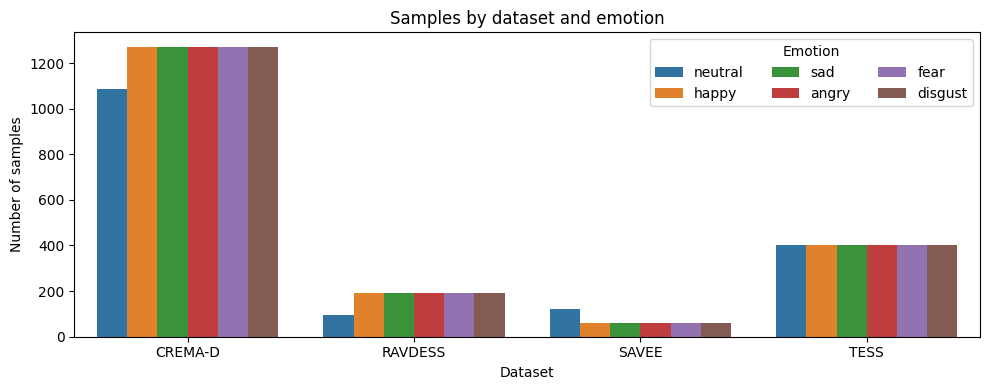

split_random,test,train,validation
dataset,,,
CREMA-D,1115,5187,1139
RAVDESS,159,751,146
SAVEE,63,293,64
TESS,361,1690,349


In [5]:
# Dataset visualization
plt.figure(figsize=(10, 4))
order = sorted(metadata["dataset"].unique())
sns.countplot(data=metadata, x="dataset", hue="emotion", order=order, hue_order=COMMON_EMOTIONS)
plt.title("Samples by dataset and emotion")
plt.xlabel("Dataset")
plt.ylabel("Number of samples")
plt.legend(title="Emotion", ncol=3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tri_view_samples_by_dataset_emotion.png", dpi=160)
plt.show()

split_table = metadata.groupby(["dataset", "split_random"]).size().unstack(fill_value=0)
display(split_table)


## 5. Feature Engineering and Tri-view Inputs

**Feature engineering** ở đây nghĩa là dùng kiến thức âm học để tạo vector số trước khi đưa vào model. Ví dụ: MFCC mô tả âm sắc, ZCR mô tả mức đổi dấu của tín hiệu, RMS mô tả năng lượng, chroma mô tả cấu trúc cao độ/harmonic, spectral contrast mô tả độ tương phản giữa vùng phổ mạnh và yếu.

Notebook ưu tiên dùng `baseline_features.npz` từ 01/02 vì file đó đã lưu vector engineered 248 chiều cho từng `sample_id`. Nếu file này không có trong Kaggle dataset, notebook tự trích xuất bộ 190-ish features theo hướng Chowdhury et al.:

```text
20 MFCC mean
+ 20 MFCC delta mean
+ 20 MFCC delta-delta mean
+ 20 MFCC std
+ 36 chroma
+ 64 log-Mel mean
+ 6 spectral contrast
+ 3 RMS statistics
+ 1 ZCR mean
= 190 dimensions
```


In [6]:
# ============================================================
# 5.1 Audio helpers
# ============================================================
def center_crop_or_pad(y, target_length=TARGET_LENGTH):
    if len(y) > target_length:
        start = (len(y) - target_length) // 2
        y = y[start:start + target_length]
    elif len(y) < target_length:
        pad = target_length - len(y)
        y = np.pad(y, (pad // 2, pad - pad // 2), mode="constant")
    return y.astype(np.float32)


def read_audio(row):
    cached = AUDIO_16K_DIR / f"{row.sample_id}.wav"
    if cached.exists():
        y, sr = sf.read(cached)
        if y.ndim > 1:
            y = y.mean(axis=1)
        if sr != TARGET_SR:
            y = librosa.resample(y.astype(np.float32), orig_sr=sr, target_sr=TARGET_SR)
    else:
        y, sr = librosa.load(row.filepath, sr=TARGET_SR, mono=True)
    y = center_crop_or_pad(y, TARGET_LENGTH)
    peak = np.max(np.abs(y)) + 1e-8
    if peak > 1.0:
        y = y / peak
    return y.astype(np.float32)


def pad_time(x, target, axis=-1):
    if x.shape[axis] > target:
        sl = [slice(None)] * x.ndim
        sl[axis] = slice(0, target)
        return x[tuple(sl)]
    if x.shape[axis] < target:
        pad_width = [(0, 0)] * x.ndim
        pad_width[axis] = (0, target - x.shape[axis])
        return np.pad(x, pad_width, mode="constant")
    return x


In [7]:
# ============================================================
# 5.2 Dual deep features: MFCC sequence + log-Mel image
# ============================================================
def extract_dual_features(row):
    y_audio = read_audio(row)
    mfcc = librosa.feature.mfcc(
        y=y_audio,
        sr=TARGET_SR,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
    )
    delta = librosa.feature.delta(mfcc)
    mfcc_feat = np.concatenate([mfcc, delta], axis=0)
    mfcc_feat = pad_time(mfcc_feat, MAX_FRAMES, axis=1).T.astype(np.float32)

    mel = librosa.feature.melspectrogram(
        y=y_audio,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )
    logmel = librosa.power_to_db(mel, ref=np.max)
    logmel = pad_time(logmel, MAX_FRAMES, axis=1).astype(np.float32)
    return mfcc_feat, logmel


cache_name = f"tri_view_dual_mfcc{N_MFCC}_mel{N_MELS}_{int(TARGET_DURATION)}s_{TARGET_SR}hz_{len(metadata)}files.npz"
cache_path = CACHE_DIR / cache_name
if CACHE_FEATURES and cache_path.exists():
    data = np.load(cache_path)
    X_mfcc = data["X_mfcc"]
    X_mel = data["X_mel"]
    y = data["y"]
    print("Loaded dual feature cache:", cache_path)
else:
    X_mfcc, X_mel = [], []
    start = time.time()
    for i, row in enumerate(metadata.itertuples(index=False)):
        a, b = extract_dual_features(row)
        X_mfcc.append(a)
        X_mel.append(b)
        if (i + 1) % 500 == 0:
            print(f"Extracted {i+1}/{len(metadata)} files in {(time.time()-start)/60:.1f} min")
    X_mfcc = np.stack(X_mfcc)
    X_mel = np.stack(X_mel)
    y = metadata["label_id"].to_numpy(np.int64)
    if CACHE_FEATURES:
        np.savez_compressed(cache_path, X_mfcc=X_mfcc, X_mel=X_mel, y=y)
        print("Saved dual feature cache:", cache_path)

MFCC_DIM = X_mfcc.shape[-1]
print("X_mfcc:", X_mfcc.shape, "X_mel:", X_mel.shape, "y:", y.shape)


Extracted 500/11317 files in 0.5 min
Extracted 1000/11317 files in 0.7 min
Extracted 1500/11317 files in 0.8 min
Extracted 2000/11317 files in 1.0 min
Extracted 2500/11317 files in 1.1 min
Extracted 3000/11317 files in 1.3 min
Extracted 3500/11317 files in 1.4 min
Extracted 4000/11317 files in 1.6 min
Extracted 4500/11317 files in 1.8 min
Extracted 5000/11317 files in 1.9 min
Extracted 5500/11317 files in 2.1 min
Extracted 6000/11317 files in 2.2 min
Extracted 6500/11317 files in 2.4 min
Extracted 7000/11317 files in 2.5 min
Extracted 7500/11317 files in 2.7 min
Extracted 8000/11317 files in 2.8 min
Extracted 8500/11317 files in 3.0 min
Extracted 9000/11317 files in 3.1 min
Extracted 9500/11317 files in 3.3 min
Extracted 10000/11317 files in 3.5 min
Extracted 10500/11317 files in 3.6 min
Extracted 11000/11317 files in 3.8 min
Saved dual feature cache: /kaggle/working/05_Tri_View_Fusion_outputs/cache/tri_view_dual_mfcc40_mel96_3s_16000hz_11317files.npz
X_mfcc: (11317, 301, 80) X_mel: (1

In [8]:
# ============================================================
# 5.3 Engineered acoustic vector features
# ============================================================
def extract_engineered_190(row):
    y_audio = read_audio(row)
    mfcc = librosa.feature.mfcc(y=y_audio, sr=TARGET_SR, n_mfcc=20, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    chroma_stft = librosa.feature.chroma_stft(y=y_audio, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    try:
        chroma_cqt = librosa.feature.chroma_cqt(y=y_audio, sr=TARGET_SR, hop_length=HOP_LENGTH)
        chroma_cens = librosa.feature.chroma_cens(y=y_audio, sr=TARGET_SR, hop_length=HOP_LENGTH)
    except Exception:
        chroma_cqt = np.zeros_like(chroma_stft)
        chroma_cens = np.zeros_like(chroma_stft)

    mel = librosa.feature.melspectrogram(y=y_audio, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, n_mels=64, power=2.0)
    logmel = librosa.power_to_db(mel, ref=np.max)
    contrast = librosa.feature.spectral_contrast(y=y_audio, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_bands=5)
    rms = librosa.feature.rms(y=y_audio, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)
    zcr = librosa.feature.zero_crossing_rate(y_audio, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)

    vec = np.concatenate([
        mfcc.mean(axis=1),
        delta.mean(axis=1),
        delta2.mean(axis=1),
        mfcc.std(axis=1),
        chroma_stft.mean(axis=1),
        chroma_cqt.mean(axis=1),
        chroma_cens.mean(axis=1),
        logmel.mean(axis=1),
        contrast.mean(axis=1),
        np.array([rms.mean(), rms.std(), rms.max()]),
        np.array([zcr.mean()]),
    ]).astype(np.float32)
    return np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)


def load_or_extract_engineered_features():
    cache_path = CACHE_DIR / f"tri_view_engineered_{len(metadata)}files.npz"
    if CACHE_FEATURES and cache_path.exists():
        data = np.load(cache_path, allow_pickle=True)
        print("Loaded engineered feature cache:", cache_path)
        return data["X_engineered"], str(data["feature_source"])

    if BASELINE_FEATURES_PATH.exists():
        base = np.load(BASELINE_FEATURES_PATH, allow_pickle=True)
        sample_ids = base["sample_id"].astype(str)
        X_base = base["X"].astype(np.float32)
        sid_to_pos = {sid: i for i, sid in enumerate(sample_ids)}
        missing = [sid for sid in metadata["sample_id"].astype(str) if sid not in sid_to_pos]
        if not missing:
            positions = [sid_to_pos[sid] for sid in metadata["sample_id"].astype(str)]
            X_engineered = X_base[positions]
            feature_source = f"baseline_features.npz ({X_engineered.shape[1]}D)"
            if CACHE_FEATURES:
                np.savez_compressed(cache_path, X_engineered=X_engineered, feature_source=feature_source)
            return X_engineered, feature_source
        print(f"baseline_features.npz exists but {len(missing)} sample_id values are missing; extracting 190-ish features instead.")

    X_engineered = []
    start = time.time()
    for i, row in enumerate(metadata.itertuples(index=False)):
        X_engineered.append(extract_engineered_190(row))
        if (i + 1) % 500 == 0:
            print(f"Engineered {i+1}/{len(metadata)} files in {(time.time()-start)/60:.1f} min")
    X_engineered = np.stack(X_engineered).astype(np.float32)
    feature_source = f"extracted_190ish_features ({X_engineered.shape[1]}D)"
    if CACHE_FEATURES:
        np.savez_compressed(cache_path, X_engineered=X_engineered, feature_source=feature_source)
    return X_engineered, feature_source


X_engineered, ENGINEERED_FEATURE_SOURCE = load_or_extract_engineered_features()
ENG_DIM = X_engineered.shape[1]
print("X_engineered:", X_engineered.shape)
print("ENGINEERED_FEATURE_SOURCE:", ENGINEERED_FEATURE_SOURCE)


X_engineered: (11317, 248)
ENGINEERED_FEATURE_SOURCE: baseline_features.npz (248D)


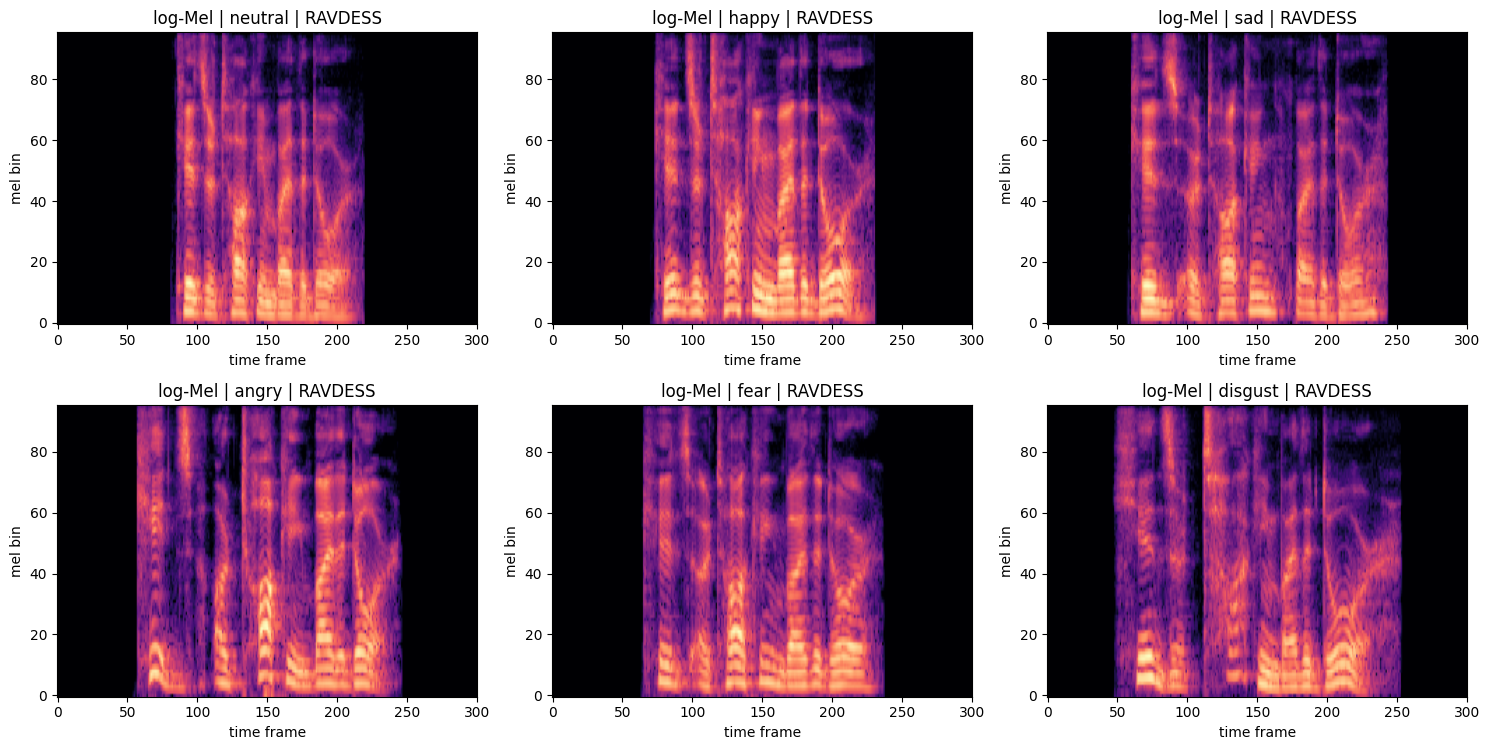

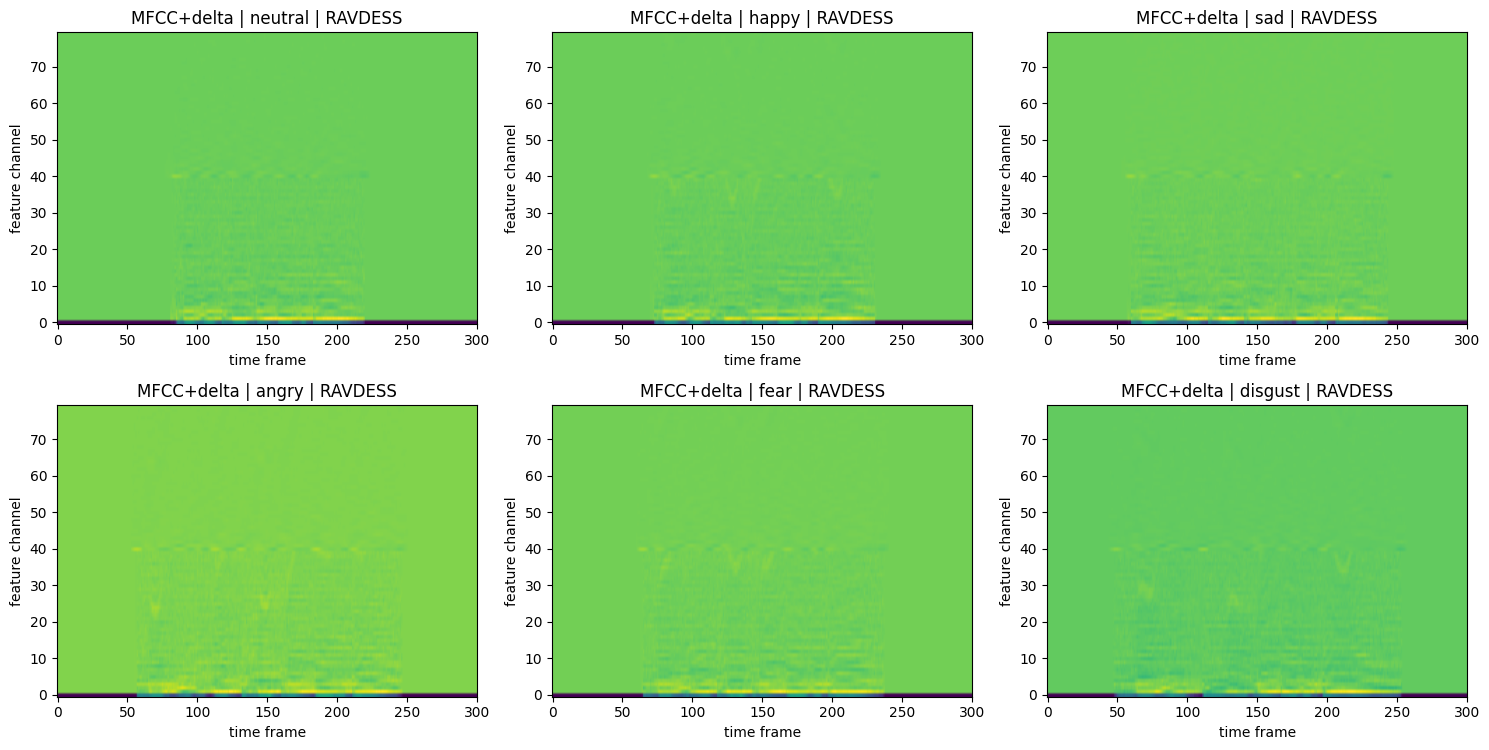

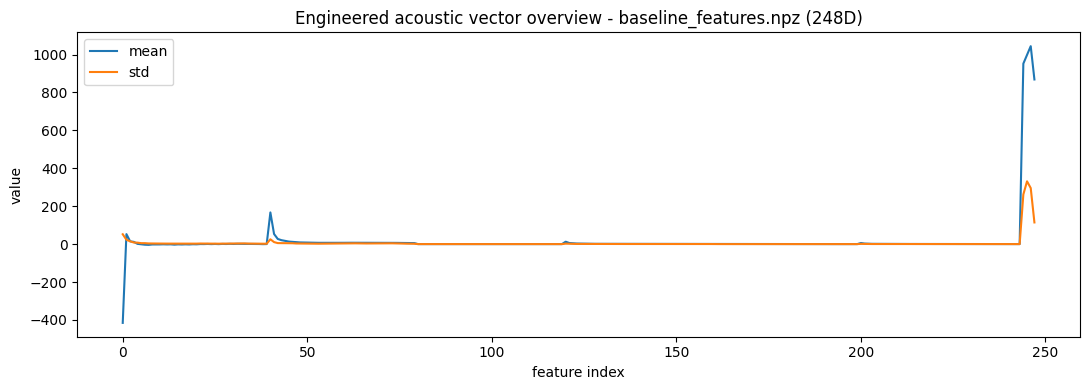

In [9]:
# Feature sanity check visualization
sample_indices = []
for emotion in COMMON_EMOTIONS:
    idx = metadata.index[metadata["emotion"].eq(emotion)]
    if len(idx):
        sample_indices.append(idx[0])

cols = min(3, len(sample_indices))
rows = int(np.ceil(len(sample_indices) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.8 * rows))
axes = np.array(axes).reshape(-1)
for ax, idx in zip(axes, sample_indices):
    ax.imshow(X_mel[idx], aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"log-Mel | {metadata.loc[idx, 'emotion']} | {metadata.loc[idx, 'dataset']}")
    ax.set_xlabel("time frame")
    ax.set_ylabel("mel bin")
for ax in axes[len(sample_indices):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tri_view_logmel_examples_by_emotion.png", dpi=160)
plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.8 * rows))
axes = np.array(axes).reshape(-1)
for ax, idx in zip(axes, sample_indices):
    ax.imshow(X_mfcc[idx].T, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(f"MFCC+delta | {metadata.loc[idx, 'emotion']} | {metadata.loc[idx, 'dataset']}")
    ax.set_xlabel("time frame")
    ax.set_ylabel("feature channel")
for ax in axes[len(sample_indices):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tri_view_mfcc_delta_examples_by_emotion.png", dpi=160)
plt.show()

eng_df = pd.DataFrame(X_engineered)
plt.figure(figsize=(11, 4))
plt.plot(eng_df.mean(axis=0).values, label="mean")
plt.plot(eng_df.std(axis=0).values, label="std")
plt.title(f"Engineered acoustic vector overview - {ENGINEERED_FEATURE_SOURCE}")
plt.xlabel("feature index")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tri_view_engineered_feature_overview.png", dpi=160)
plt.show()


## 6. Dataset Class and Train-only Augmentation

Augmentation chỉ áp dụng trên train set:

- time shift trên MFCC/log-Mel;
- Gaussian noise nhẹ trên feature;
- time masking và frequency masking kiểu SpecAugment;
- mixup trong training loop để giảm overfit.

Do notebook ưu tiên tốc độ Kaggle, augmentation chính ở mức feature. Nếu muốn giống paper hơn nữa, bước sau có thể thêm raw-audio augmentation ở 01/02 hoặc tạo cache augmented audio riêng.


In [10]:
# ============================================================
# 6. Data scaling, augmentation and loaders
# ============================================================
def compute_scalers(train_idx):
    mfcc_mean = X_mfcc[train_idx].mean(axis=(0, 1), keepdims=True)
    mfcc_std = X_mfcc[train_idx].std(axis=(0, 1), keepdims=True) + 1e-6
    mel_mean = X_mel[train_idx].mean()
    mel_std = X_mel[train_idx].std() + 1e-6
    eng_scaler = StandardScaler()
    eng_scaler.fit(X_engineered[train_idx])
    return mfcc_mean.astype(np.float32), mfcc_std.astype(np.float32), float(mel_mean), float(mel_std), eng_scaler


def augment_triplet(mfcc, mel, eng):
    if not USE_AUGMENTATION:
        return mfcc, mel, eng
    if random.random() < 0.35:
        shift = random.randint(-16, 16)
        mfcc = np.roll(mfcc, shift, axis=0)
        mel = np.roll(mel, shift, axis=1)
    if random.random() < 0.35:
        mfcc = mfcc + np.random.normal(0, 0.02, mfcc.shape).astype(np.float32)
        mel = mel + np.random.normal(0, 0.02, mel.shape).astype(np.float32)
        eng = eng + np.random.normal(0, 0.015, eng.shape).astype(np.float32)
    if random.random() < 0.45:
        width = random.randint(8, 32)
        start = random.randint(0, max(0, mfcc.shape[0] - width))
        mfcc[start:start + width, :] = 0
        mel[:, start:start + width] = 0
    if random.random() < 0.45:
        width = random.randint(6, 18)
        start = random.randint(0, max(0, mel.shape[0] - width))
        mel[start:start + width, :] = 0
    return mfcc, mel, eng


class TriViewDataset(Dataset):
    def __init__(self, indices, scalers, train=False):
        self.indices = np.array(indices)
        self.mfcc_mean, self.mfcc_std, self.mel_mean, self.mel_std, self.eng_scaler = scalers
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        mfcc = ((X_mfcc[i] - self.mfcc_mean.squeeze(0)) / self.mfcc_std.squeeze(0)).astype(np.float32)
        mel = ((X_mel[i] - self.mel_mean) / self.mel_std).astype(np.float32)
        eng = self.eng_scaler.transform(X_engineered[i:i + 1]).astype(np.float32)[0]
        if self.train:
            mfcc, mel, eng = augment_triplet(mfcc.copy(), mel.copy(), eng.copy())
        return (
            torch.from_numpy(mfcc.T),
            torch.from_numpy(mel[None, :, :]),
            torch.from_numpy(eng),
            torch.tensor(y[i], dtype=torch.long),
        )


def make_loaders(split_map):
    train_idx, val_idx, test_idx = split_map["train"], split_map["validation"], split_map["test"]
    scalers = compute_scalers(train_idx)
    loaders = {
        "train": DataLoader(TriViewDataset(train_idx, scalers, train=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=0),
        "validation": DataLoader(TriViewDataset(val_idx, scalers, train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
        "test": DataLoader(TriViewDataset(test_idx, scalers, train=False), batch_size=BATCH_SIZE, shuffle=False, num_workers=0),
    }
    return loaders, scalers


## 7. Tri-view Model Architectures

Notebook có 3 variant:

- **engineered_mlp**: chỉ dùng vector engineered features. Variant này kiểm tra xem feature engineering tự nó mạnh đến đâu.
- **tri_gated**: MFCC 1D-CNN branch + log-Mel 2D-CNN branch + engineered MLP branch, sau đó dùng gate để học nên tin nhánh nào nhiều hơn.
- **tri_bigru**: giống `tri_gated`, nhưng MFCC branch thêm BiGRU để học ngữ cảnh thời gian dài hơn.


In [11]:
# ============================================================
# 7. Model definitions
# ============================================================
class SE1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.net(x).unsqueeze(-1)


class SE2D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.net(x).view(x.size(0), x.size(1), 1, 1)


class AttentionPool1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Conv1d(channels, max(16, channels // 2), 1),
            nn.Tanh(),
            nn.Conv1d(max(16, channels // 2), 1, 1),
        )

    def forward(self, x):
        w = torch.softmax(self.attn(x), dim=-1)
        return (x * w).sum(dim=-1)


class ResConv1DBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=5, dilation=1, dropout=DROPOUT):
        super().__init__()
        pad = dilation * (kernel // 2)
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
        )
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.se = SE1D(out_ch)
        self.pool = nn.MaxPool1d(2)

    def forward(self, x):
        return self.pool(self.se(self.conv(x) + self.shortcut(x)))


class MFCCBranch(nn.Module):
    def __init__(self, in_channels, embed_dim=192):
        super().__init__()
        self.blocks = nn.Sequential(
            ResConv1DBlock(in_channels, 80, dilation=1),
            ResConv1DBlock(80, 128, dilation=2),
            ResConv1DBlock(128, 192, dilation=3),
        )
        self.pool = AttentionPool1D(192)
        self.proj = nn.Sequential(nn.Linear(192, embed_dim), nn.LayerNorm(embed_dim), nn.GELU(), nn.Dropout(DROPOUT))

    def forward(self, x):
        seq = self.blocks(x)
        emb = self.proj(self.pool(seq))
        return emb, seq.transpose(1, 2)


class MelBranch(nn.Module):
    def __init__(self, embed_dim=192):
        super().__init__()

        def block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1),
                nn.BatchNorm2d(o),
                nn.GELU(),
                nn.Conv2d(o, o, 3, padding=1),
                nn.BatchNorm2d(o),
                nn.GELU(),
                SE2D(o),
                nn.MaxPool2d(2),
                nn.Dropout2d(0.12),
            )

        self.cnn = nn.Sequential(block(1, 32), block(32, 64), block(64, 128), block(128, 160))
        self.proj = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(160, embed_dim), nn.LayerNorm(embed_dim), nn.GELU(), nn.Dropout(DROPOUT))

    def forward(self, x):
        return self.proj(self.cnn(x))


class EngineeredBranch(nn.Module):
    def __init__(self, in_dim, embed_dim=192):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        return self.net(x)


class TriGatedFusionSER(nn.Module):
    def __init__(self, mfcc_dim, eng_dim, num_classes, embed_dim=192, use_bigru=False):
        super().__init__()
        self.use_bigru = use_bigru
        self.mfcc = MFCCBranch(mfcc_dim, embed_dim)
        self.mel = MelBranch(embed_dim)
        self.eng = EngineeredBranch(eng_dim, embed_dim)
        if use_bigru:
            self.gru = nn.GRU(192, 96, batch_first=True, bidirectional=True)
            self.gru_proj = nn.Sequential(nn.Linear(192, embed_dim), nn.LayerNorm(embed_dim), nn.GELU(), nn.Dropout(DROPOUT))
        self.gate = nn.Sequential(
            nn.Linear(embed_dim * 3, embed_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(embed_dim, 3),
        )
        self.cls = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(DROPOUT),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, num_classes),
        )

    def forward(self, mfcc, mel, eng):
        mfcc_emb, seq = self.mfcc(mfcc)
        if self.use_bigru:
            out, _ = self.gru(seq.contiguous())
            mfcc_emb = self.gru_proj(out.mean(dim=1))
        mel_emb = self.mel(mel)
        eng_emb = self.eng(eng)
        gate_logits = self.gate(torch.cat([mfcc_emb, mel_emb, eng_emb], dim=1))
        weights = torch.softmax(gate_logits, dim=1).unsqueeze(-1)
        branches = torch.stack([mfcc_emb, mel_emb, eng_emb], dim=1)
        fused = (weights * branches).sum(dim=1)
        return self.cls(fused)


class EngineeredMLPOnly(nn.Module):
    def __init__(self, mfcc_dim, eng_dim, num_classes, embed_dim=192):
        super().__init__()
        self.eng = EngineeredBranch(eng_dim, embed_dim)
        self.cls = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(DROPOUT),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, num_classes),
        )

    def forward(self, mfcc, mel, eng):
        return self.cls(self.eng(eng))


def build_model(variant):
    if variant == "tri_gated":
        return TriGatedFusionSER(MFCC_DIM, ENG_DIM, len(COMMON_EMOTIONS), use_bigru=False).to(DEVICE)
    if variant == "tri_bigru":
        return TriGatedFusionSER(MFCC_DIM, ENG_DIM, len(COMMON_EMOTIONS), use_bigru=True).to(DEVICE)
    if variant == "engineered_mlp":
        return EngineeredMLPOnly(MFCC_DIM, ENG_DIM, len(COMMON_EMOTIONS)).to(DEVICE)
    raise ValueError(f"Unknown variant: {variant}")


for variant in MODEL_VARIANTS:
    m = build_model(variant)
    print(variant, "parameters:", sum(p.numel() for p in m.parameters()))
    del m
torch.cuda.empty_cache()


tri_gated parameters: 1611264
tri_bigru parameters: 1815744
engineered_mlp parameters: 139846


In [12]:
# ============================================================
# 8. Training and evaluation helpers
# ============================================================
def class_weights_for(indices):
    counts = np.bincount(y[indices], minlength=len(COMMON_EMOTIONS)).astype(np.float32)
    weights = counts.sum() / (len(COMMON_EMOTIONS) * np.maximum(counts, 1))
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def maybe_mixup(mfcc, mel, eng, target):
    if (not USE_AUGMENTATION) or MIXUP_ALPHA <= 0 or random.random() > MIXUP_PROB:
        return mfcc, mel, eng, target, None, 1.0
    lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
    perm = torch.randperm(mfcc.size(0), device=mfcc.device)
    mfcc = lam * mfcc + (1 - lam) * mfcc[perm]
    mel = lam * mel + (1 - lam) * mel[perm]
    eng = lam * eng + (1 - lam) * eng[perm]
    return mfcc, mel, eng, target, target[perm], lam


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, all_y, all_pred, all_prob = 0.0, [], [], []
    for mfcc, mel, eng, target in loader:
        mfcc, mel, eng, target = mfcc.to(DEVICE), mel.to(DEVICE), eng.to(DEVICE), target.to(DEVICE)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            mfcc_in, mel_in, eng_in, target_a, target_b, lam = maybe_mixup(mfcc, mel, eng, target)
        else:
            mfcc_in, mel_in, eng_in, target_a, target_b, lam = mfcc, mel, eng, target, None, 1.0

        with torch.set_grad_enabled(is_train):
            logits = model(mfcc_in, mel_in, eng_in)
            if is_train and target_b is not None:
                loss = lam * criterion(logits, target_a) + (1 - lam) * criterion(logits, target_b)
            else:
                loss = criterion(logits, target)
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

        with torch.no_grad():
            eval_logits = model(mfcc, mel, eng) if is_train and target_b is not None else logits
            prob = torch.softmax(eval_logits.detach(), dim=1)
        total_loss += loss.item() * len(target)
        all_y.extend(target.detach().cpu().numpy())
        all_pred.extend(prob.argmax(dim=1).cpu().numpy())
        all_prob.extend(prob.cpu().numpy())

    all_y = np.array(all_y)
    all_pred = np.array(all_pred)
    all_prob = np.array(all_prob)
    return {
        "loss": total_loss / max(1, len(all_y)),
        "accuracy": accuracy_score(all_y, all_pred),
        "macro_f1": f1_score(all_y, all_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(all_y, all_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(all_y, all_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(all_y, all_pred, average="macro", zero_division=0),
        "y_true": all_y,
        "y_pred": all_pred,
        "prob": all_prob,
    }


def plot_confusion(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(COMMON_EMOTIONS))))
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=COMMON_EMOTIONS, yticklabels=COMMON_EMOTIONS)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    plt.close()


In [13]:
def train_one(run_name, variant, split_map):
    loaders, scalers = make_loaders(split_map)
    model = build_model(variant)
    weights = class_weights_for(split_map["train"]) if USE_CLASS_WEIGHTS else None
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_state, best_val, best_epoch, stale = None, -1.0, 0, 0
    history = []
    start = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        tr = run_epoch(model, loaders["train"], criterion, optimizer)
        va = run_epoch(model, loaders["validation"], criterion, None)
        scheduler.step(va["macro_f1"])
        row = {
            "run_name": run_name,
            "variant": variant,
            "epoch": epoch,
            "train_loss": tr["loss"],
            "train_macro_f1": tr["macro_f1"],
            "val_loss": va["loss"],
            "val_macro_f1": va["macro_f1"],
            "val_accuracy": va["accuracy"],
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(f"{run_name} | {variant} | epoch {epoch:02d} | train f1 {tr['macro_f1']:.4f} | val f1 {va['macro_f1']:.4f}")
        if va["macro_f1"] > best_val:
            best_val, best_epoch, stale = va["macro_f1"], epoch, 0
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= PATIENCE:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    t0 = time.time()
    te = run_epoch(model, loaders["test"], criterion, None)
    inference_time = time.time() - t0
    train_time = time.time() - start

    torch.save(
        {
            "model_state": best_state,
            "variant": variant,
            "run_name": run_name,
            "best_epoch": best_epoch,
            "config": {
                "N_MFCC": N_MFCC,
                "N_MELS": N_MELS,
                "ENG_DIM": ENG_DIM,
                "ENGINEERED_FEATURE_SOURCE": ENGINEERED_FEATURE_SOURCE,
                "TARGET_DURATION": TARGET_DURATION,
                "COMMON_EMOTIONS": COMMON_EMOTIONS,
            },
        },
        MODEL_DIR / f"{run_name}_{variant}.pt",
    )

    test_indices = split_map["test"]
    pred_df = metadata.loc[test_indices, ["sample_id", "dataset", "speaker_id", "emotion"]].copy()
    pred_df["y_true"] = te["y_true"]
    pred_df["y_pred"] = te["y_pred"]
    pred_df["pred_emotion"] = [ID_TO_LABEL[i] for i in te["y_pred"]]
    for i, label in ID_TO_LABEL.items():
        pred_df[f"prob_{label}"] = te["prob"][:, i]
    pred_df.to_csv(PRED_DIR / f"predictions_{run_name}_{variant}.csv", index=False)
    plot_confusion(te["y_true"], te["y_pred"], f"{run_name} {variant}", FIGURE_DIR / f"confusion_matrix_{run_name}_{variant}.png")

    report = classification_report(te["y_true"], te["y_pred"], labels=list(range(len(COMMON_EMOTIONS))), target_names=COMMON_EMOTIONS, output_dict=True, zero_division=0)
    per_class = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})
    per_class.insert(0, "variant", variant)
    per_class.insert(0, "run_name", run_name)
    per_class.to_csv(REPORT_DIR / f"per_class_{run_name}_{variant}.csv", index=False)

    per_dataset = []
    for ds, part in pred_df.groupby("dataset"):
        per_dataset.append({
            "run_name": run_name,
            "variant": variant,
            "dataset": ds,
            "n_samples": len(part),
            "accuracy": accuracy_score(part["y_true"], part["y_pred"]),
            "macro_f1": f1_score(part["y_true"], part["y_pred"], average="macro", zero_division=0),
        })

    metric = {
        "run_name": run_name,
        "variant": variant,
        "split": "test",
        "n_samples": len(te["y_true"]),
        "loss": te["loss"],
        "accuracy": te["accuracy"],
        "macro_f1": te["macro_f1"],
        "weighted_f1": te["weighted_f1"],
        "macro_precision": te["macro_precision"],
        "macro_recall": te["macro_recall"],
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val,
        "train_time_sec": train_time,
        "inference_time_sec": inference_time,
        "inference_ms_per_sample": 1000 * inference_time / max(1, len(te["y_true"])),
        "engineered_feature_source": ENGINEERED_FEATURE_SOURCE,
    }
    return metric, history, per_dataset


In [14]:
# ============================================================
# 9. Build experiment list
# ============================================================
def split_from_column(col, include_mask=None):
    df = metadata if include_mask is None else metadata[include_mask]
    split_values = df[col].to_numpy()
    indices = df.index.to_numpy()
    out = {s: indices[split_values == s] for s in ["train", "validation", "test"]}
    if len(out["validation"]) == 0 and len(out["train"]) > 10:
        train_sub, val_sub = train_test_split(out["train"], test_size=0.12, random_state=SEED, stratify=y[out["train"]])
        out["train"], out["validation"] = train_sub, val_sub
    return out


experiments = []
if RUN_COMBINED_RANDOM:
    experiments.append(("combined_random", split_from_column("split_random")))
if RUN_COMBINED_STRICT:
    strict_mask = metadata["split_strict_project"].isin(["train", "validation", "test"])
    experiments.append(("combined_strict_no_tess", split_from_column("split_strict_project", strict_mask)))
if RUN_SINGLE_DATASET:
    for ds in sorted(metadata["dataset"].unique()):
        ds_df = metadata[metadata["dataset"].eq(ds)]
        idx_train, idx_temp = train_test_split(ds_df.index, test_size=0.30, random_state=SEED, stratify=metadata.loc[ds_df.index, "label_id"])
        idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED, stratify=metadata.loc[idx_temp, "label_id"])
        experiments.append((f"single_{ds}", {"train": np.array(idx_train), "validation": np.array(idx_val), "test": np.array(idx_test)}))

for name, split_map in experiments:
    print(name, {k: len(v) for k, v in split_map.items()})


combined_random {'train': 7921, 'validation': 1698, 'test': 1698}
combined_strict_no_tess {'train': 6110, 'validation': 854, 'test': 1953}
single_CREMA-D {'train': 5208, 'validation': 1116, 'test': 1117}
single_RAVDESS {'train': 739, 'validation': 158, 'test': 159}
single_SAVEE {'train': 294, 'validation': 63, 'test': 63}
single_TESS {'train': 1680, 'validation': 360, 'test': 360}


In [15]:
# ============================================================
# 10. Run training
# ============================================================
all_metrics, all_history, all_per_dataset = [], [], []

for run_name, split_map in experiments:
    for variant in MODEL_VARIANTS:
        print("\n" + "=" * 80)
        print("RUN:", run_name, "| MODEL:", variant)
        metric, history, per_dataset = train_one(run_name, variant, split_map)
        all_metrics.append(metric)
        all_history.extend(history)
        all_per_dataset.extend(per_dataset)
        pd.DataFrame(all_metrics).to_csv(REPORT_DIR / "tri_view_metrics_partial.csv", index=False)
        pd.DataFrame(all_history).to_csv(REPORT_DIR / "tri_view_history_partial.csv", index=False)
        pd.DataFrame(all_per_dataset).to_csv(REPORT_DIR / "tri_view_per_dataset_partial.csv", index=False)

metrics_df = pd.DataFrame(all_metrics)
history_df = pd.DataFrame(all_history)
per_dataset_df = pd.DataFrame(all_per_dataset)

metrics_df.to_csv(REPORT_DIR / "tri_view_metrics.csv", index=False)
history_df.to_csv(REPORT_DIR / "tri_view_history.csv", index=False)
per_dataset_df.to_csv(REPORT_DIR / "tri_view_per_dataset.csv", index=False)

display(metrics_df.sort_values(["run_name", "macro_f1"], ascending=[True, False]))



RUN: combined_random | MODEL: tri_gated
combined_random | tri_gated | epoch 01 | train f1 0.4224 | val f1 0.5553
combined_random | tri_gated | epoch 02 | train f1 0.5462 | val f1 0.5935
combined_random | tri_gated | epoch 03 | train f1 0.5874 | val f1 0.6098
combined_random | tri_gated | epoch 04 | train f1 0.6225 | val f1 0.6316
combined_random | tri_gated | epoch 05 | train f1 0.6446 | val f1 0.6424
combined_random | tri_gated | epoch 06 | train f1 0.6707 | val f1 0.6482
combined_random | tri_gated | epoch 07 | train f1 0.6832 | val f1 0.6617
combined_random | tri_gated | epoch 08 | train f1 0.7174 | val f1 0.6613
combined_random | tri_gated | epoch 09 | train f1 0.7255 | val f1 0.6595
combined_random | tri_gated | epoch 10 | train f1 0.7468 | val f1 0.6747
combined_random | tri_gated | epoch 11 | train f1 0.7648 | val f1 0.6725
combined_random | tri_gated | epoch 12 | train f1 0.7820 | val f1 0.6826
combined_random | tri_gated | epoch 13 | train f1 0.7974 | val f1 0.6611
combined_r

,run_name,variant,split,n_samples,loss,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,best_epoch,best_val_macro_f1,train_time_sec,inference_time_sec,inference_ms_per_sample,engineered_feature_source
1,combined_random,tri_bigru,test,1698,1.000418,0.724382,0.723994,0.723571,0.728214,0.725870,17,0.704822,3641.379246,11.489820,6.766678,baseline_features.npz (248D)
0,combined_random,tri_gated,test,1698,1.085352,0.716137,0.717123,0.715641,0.723208,0.718126,19,0.711747,3861.478724,11.518886,6.783796,baseline_features.npz (248D)
2,combined_random,engineered_mlp,test,1698,1.120532,0.681390,0.680747,0.680847,0.684603,0.683317,31,0.665015,369.134172,0.623834,0.367393,baseline_features.npz (248D)
4,combined_strict_no_tess,tri_bigru,test,1953,1.614182,0.541731,0.541905,0.540935,0.545905,0.543553,18,0.536094,2808.394786,13.995155,7.165978,baseline_features.npz (248D)
3,combined_strict_no_tess,tri_gated,test,1953,1.753673,0.537122,0.536062,0.535301,0.554715,0.540839,18,0.567405,2800.553325,13.186115,6.751723,baseline_features.npz (248D)
5,combined_strict_no_tess,engineered_mlp,test,1953,1.659521,0.477215,0.477531,0.477148,0.492713,0.480501,19,0.490230,209.742950,0.758347,0.388299,baseline_features.npz (248D)
6,single_CREMA-D,tri_gated,test,1117,1.339297,0.609669,0.610195,0.608923,0.613954,0.612226,19,0.620838,2614.154666,7.728158,6.918673,baseline_features.npz (248D)
7,single_CREMA-D,tri_bigru,test,1117,1.378944,0.603402,0.602688,0.601087,0.607046,0.604219,21,0.613546,2726.025247,7.582829,6.788566,baseline_features.npz (248D)
8,single_CREMA-D,engineered_mlp,test,1117,1.433387,0.567592,0.562876,0.563108,0.563278,0.567090,30,0.587622,235.839363,0.406082,0.363547,baseline_features.npz (248D)
9,single_RAVDESS,tri_gated,test,159,1.145779,0.710692,0.720200,0.710069,0.739930,0.723317,35,0.764870,552.604844,1.072006,6.742179,baseline_features.npz (248D)


## 11. Result Visualization

Các biểu đồ dưới đây dùng để kiểm tra:

- model nào tốt nhất theo từng protocol;
- có overfit không qua train/validation curve;
- dataset nào đang kéo điểm xuống;
- emotion nào dễ nhầm nhau qua confusion matrix và per-class F1.


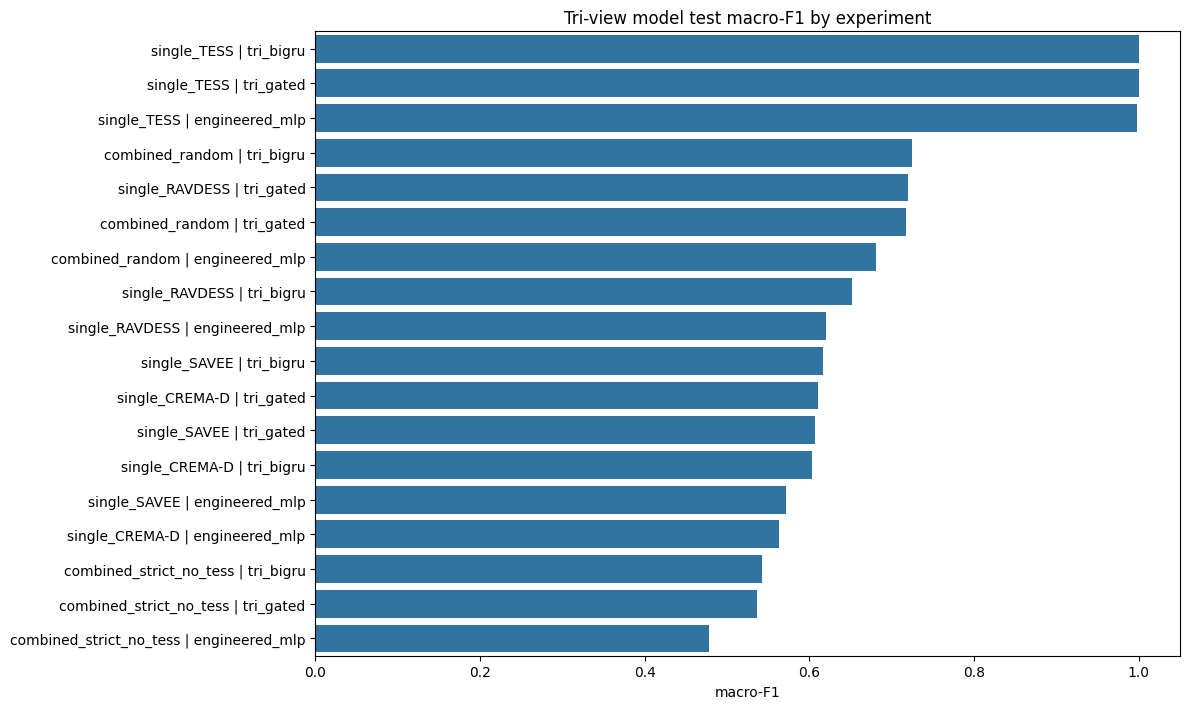

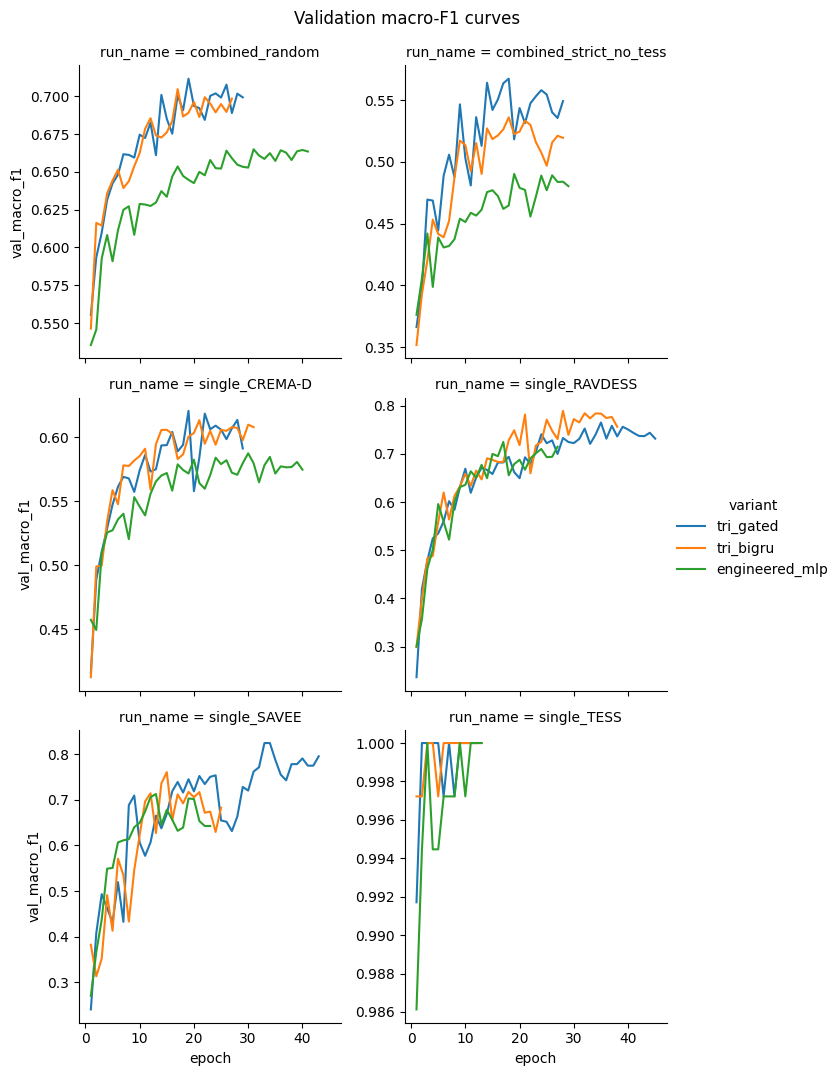

dataset                                  CREMA-D   RAVDESS     SAVEE      TESS
run_name                variant                                               
combined_random         engineered_mlp  0.581385  0.689934  0.492107  0.997346
                        tri_bigru       0.632548  0.693637  0.601735  1.000000
                        tri_gated       0.620269  0.746901  0.608953  0.997307
combined_strict_no_tess engineered_mlp  0.490555  0.336641  0.221382       NaN
                        tri_bigru       0.563265  0.348560  0.242682       NaN
                        tri_gated       0.550209  0.449742  0.193837       NaN
single_CREMA-D          engineered_mlp  0.562876       NaN       NaN       NaN
                        tri_bigru       0.602688       NaN       NaN       NaN
                        tri_gated       0.610195       NaN       NaN       NaN
single_RAVDESS          engineered_mlp       NaN  0.620565       NaN       NaN
                        tri_bigru            NaN  0.652114       NaN       NaN
                        tri_gated            NaN  0.720200       NaN       NaN
single_SAVEE            engineered_mlp       NaN       NaN  0.571078       NaN
                        tri_bigru            NaN       NaN  0.616594       NaN
                        tri_gated            NaN       NaN  0.606429       NaN
single_TESS             engineered_mlp       NaN       NaN       NaN  0.997222
                        tri_bigru            NaN       NaN       NaN  1.000000
                        tri_gated            NaN       NaN       NaN  1.000000

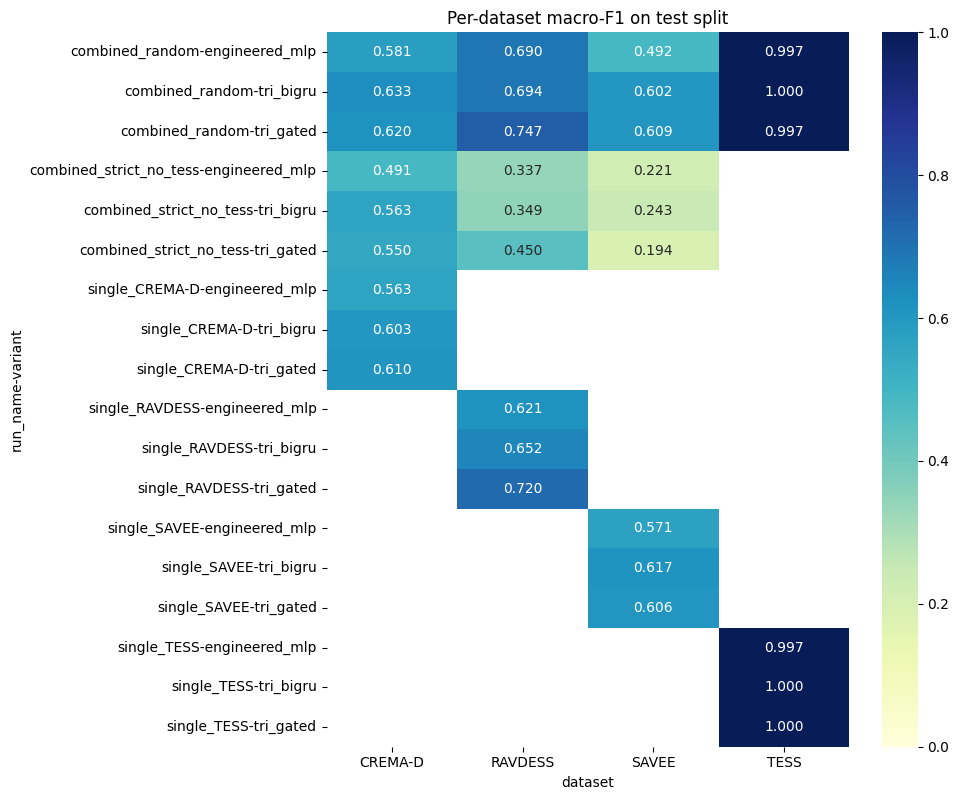

In [16]:
if len(metrics_df):
    plt.figure(figsize=(12, max(5, 0.4 * len(metrics_df))))
    plot_df = metrics_df.copy()
    plot_df["label"] = plot_df["run_name"] + " | " + plot_df["variant"]
    plot_df = plot_df.sort_values("macro_f1", ascending=False)
    sns.barplot(data=plot_df, y="label", x="macro_f1", orient="h")
    plt.title("Tri-view model test macro-F1 by experiment")
    plt.xlabel("macro-F1")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "tri_view_macro_f1_by_experiment.png", dpi=160)
    plt.show()

if len(history_df):
    g = sns.relplot(
        data=history_df,
        x="epoch",
        y="val_macro_f1",
        hue="variant",
        col="run_name",
        col_wrap=2,
        kind="line",
        height=3.5,
        facet_kws={"sharey": False},
    )
    g.fig.suptitle("Validation macro-F1 curves", y=1.02)
    plt.savefig(FIGURE_DIR / "tri_view_validation_curves.png", dpi=160, bbox_inches="tight")
    plt.show()

if len(per_dataset_df):
    pivot = per_dataset_df.pivot_table(index=["run_name", "variant"], columns="dataset", values="macro_f1", aggfunc="mean")
    display(pivot)
    plt.figure(figsize=(10, max(4, 0.45 * len(pivot))))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
    plt.title("Per-dataset macro-F1 on test split")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "tri_view_per_dataset_macro_f1_heatmap.png", dpi=160)
    plt.show()


class                                      angry   disgust      fear  \
run_name                variant                                        
combined_random         engineered_mlp  0.775862  0.677656  0.653430   
                        tri_bigru       0.795053  0.728261  0.661509   
                        tri_gated       0.776770  0.688716  0.649215   
combined_strict_no_tess engineered_mlp  0.598230  0.444079  0.406400   
                        tri_bigru       0.644737  0.490166  0.438538   
                        tri_gated       0.624549  0.488136  0.435940   
single_CREMA-D          engineered_mlp  0.712195  0.517520  0.492997   
                        tri_bigru       0.719388  0.531856  0.529563   
                        tri_gated       0.714286  0.516291  0.568116   
single_RAVDESS          engineered_mlp  0.723404  0.771429  0.566038   
                        tri_bigru       0.814815  0.857143  0.531250   
                        tri_gated       0.765957  0.800000  0.566038   
single_SAVEE            engineered_mlp  0.555556  0.444444  0.705882   
                        tri_bigru       0.588235  0.500000  0.666667   
                        tri_gated       0.545455  0.666667  0.631579   
single_TESS             engineered_mlp  0.991736  1.000000  0.991597   
                        tri_bigru       1.000000  1.000000  1.000000   
                        tri_gated       1.000000  1.000000  1.000000   

class                                      happy   neutral       sad  
run_name                variant                                       
combined_random         engineered_mlp  0.642066  0.673401  0.662069  
                        tri_bigru       0.711636  0.744102  0.703404  
                        tri_gated       0.680412  0.792453  0.715170  
combined_strict_no_tess engineered_mlp  0.390016  0.496715  0.529745  
                        tri_bigru       0.544444  0.590476  0.543066  
                        tri_gated       0.548431  0.574124  0.545190  
single_CREMA-D          engineered_mlp  0.498599  0.548287  0.607656  
                        tri_bigru       0.538682  0.662379  0.634259  
                        tri_gated       0.556474  0.657224  0.648780  
single_RAVDESS          engineered_mlp  0.586207  0.551724  0.524590  
                        tri_bigru       0.545455  0.571429  0.592593  
                        tri_gated       0.655738  0.827586  0.705882  
single_SAVEE            engineered_mlp  0.470588  0.750000  0.500000  
                        tri_bigru       0.608696  0.727273  0.608696  
                        tri_gated       0.307692  0.820513  0.666667  
single_TESS             engineered_mlp  1.000000  1.000000  1.000000  
                        tri_bigru       1.000000  1.000000  1.000000  
                        tri_gated       1.000000  1.000000  1.000000

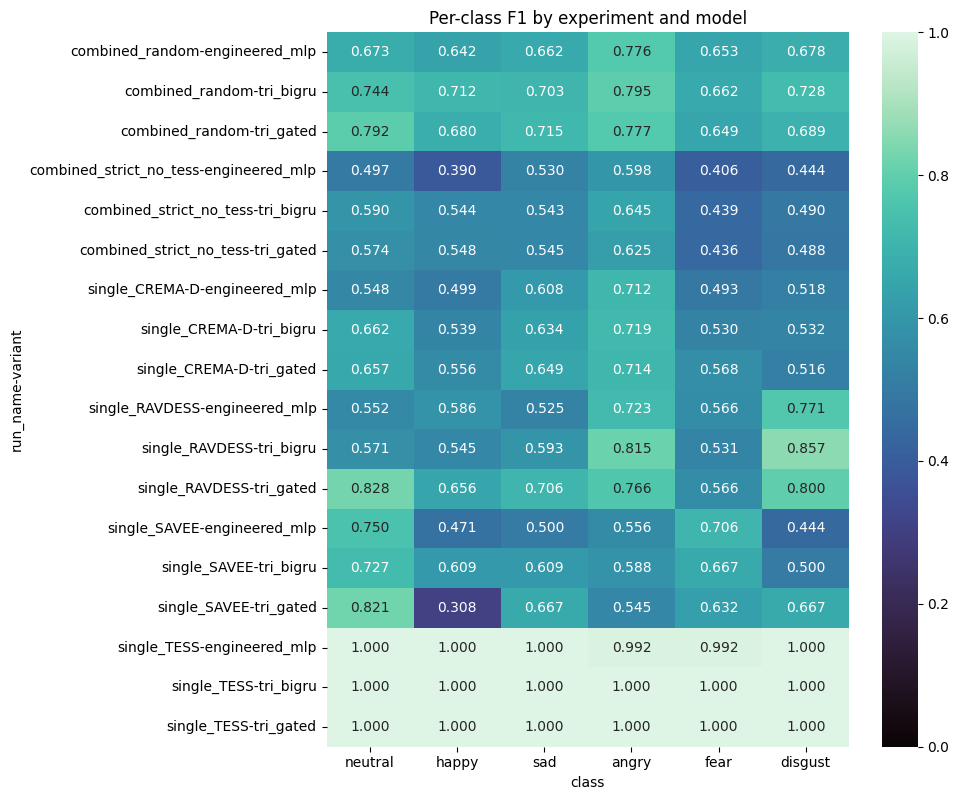

In [17]:
# Per-class F1 summary from saved per-class reports
per_class_files = sorted(REPORT_DIR.glob("per_class_*.csv"))
per_class_rows = []
for p in per_class_files:
    df = pd.read_csv(p)
    df = df[df["class"].isin(COMMON_EMOTIONS)].copy()
    per_class_rows.append(df)

if per_class_rows:
    per_class_df = pd.concat(per_class_rows, ignore_index=True)
    per_class_df.to_csv(REPORT_DIR / "tri_view_per_class_all.csv", index=False)
    pivot = per_class_df.pivot_table(index=["run_name", "variant"], columns="class", values="f1-score", aggfunc="mean")
    display(pivot)
    plt.figure(figsize=(10, max(4, 0.45 * len(pivot))))
    sns.heatmap(pivot[COMMON_EMOTIONS], annot=True, fmt=".3f", cmap="mako", vmin=0, vmax=1)
    plt.title("Per-class F1 by experiment and model")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "tri_view_per_class_f1_heatmap.png", dpi=160)
    plt.show()


In [18]:
# Confusion matrix gallery
confusion_paths = sorted(FIGURE_DIR.glob("confusion_matrix_*.png"))
print(f"Saved confusion matrices: {len(confusion_paths)}")
for p in confusion_paths[:12]:
    print(p.name)


Saved confusion matrices: 18
confusion_matrix_combined_random_engineered_mlp.png
confusion_matrix_combined_random_tri_bigru.png
confusion_matrix_combined_random_tri_gated.png
confusion_matrix_combined_strict_no_tess_engineered_mlp.png
confusion_matrix_combined_strict_no_tess_tri_bigru.png
confusion_matrix_combined_strict_no_tess_tri_gated.png
confusion_matrix_single_CREMA-D_engineered_mlp.png
confusion_matrix_single_CREMA-D_tri_bigru.png
confusion_matrix_single_CREMA-D_tri_gated.png
confusion_matrix_single_RAVDESS_engineered_mlp.png
confusion_matrix_single_RAVDESS_tri_bigru.png
confusion_matrix_single_RAVDESS_tri_gated.png


## 12. Comparison with Baseline 04 and Literature

Bảng này giúp báo cáo dễ đọc hơn:

- `our_04_baseline`: classical ML baseline từ notebook 04.
- `our_05_tri_view`: mô hình đề xuất mới.
- `reference`: kết quả paper, dùng để đặt bối cảnh. Không so sánh tuyệt đối nếu protocol khác, đặc biệt khi paper dùng random split hoặc single-dataset split không speaker-aware.


Baseline output not found yet. Run notebook 04 first if you want automatic comparison.


,source,protocol,model,accuracy,macro_f1,reported_accuracy_text,note
16,our_05_tri_view,single_TESS,tri_bigru,1.000000,1.000000,,Tri-view model: MFCC sequence + log-Mel image ...
15,our_05_tri_view,single_TESS,tri_gated,1.000000,1.000000,,Tri-view model: MFCC sequence + log-Mel image ...
17,our_05_tri_view,single_TESS,engineered_mlp,0.997222,0.997222,,Tri-view model: MFCC sequence + log-Mel image ...
1,our_05_tri_view,combined_random,tri_bigru,0.724382,0.723994,,Tri-view model: MFCC sequence + log-Mel image ...
9,our_05_tri_view,single_RAVDESS,tri_gated,0.710692,0.720200,,Tri-view model: MFCC sequence + log-Mel image ...
0,our_05_tri_view,combined_random,tri_gated,0.716137,0.717123,,Tri-view model: MFCC sequence + log-Mel image ...
2,our_05_tri_view,combined_random,engineered_mlp,0.681390,0.680747,,Tri-view model: MFCC sequence + log-Mel image ...
10,our_05_tri_view,single_RAVDESS,tri_bigru,0.660377,0.652114,,Tri-view model: MFCC sequence + log-Mel image ...
11,our_05_tri_view,single_RAVDESS,engineered_mlp,0.628931,0.620565,,Tri-view model: MFCC sequence + log-Mel image ...
13,our_05_tri_view,single_SAVEE,tri_bigru,0.634921,0.616594,,Tri-view model: MFCC sequence + log-Mel image ...


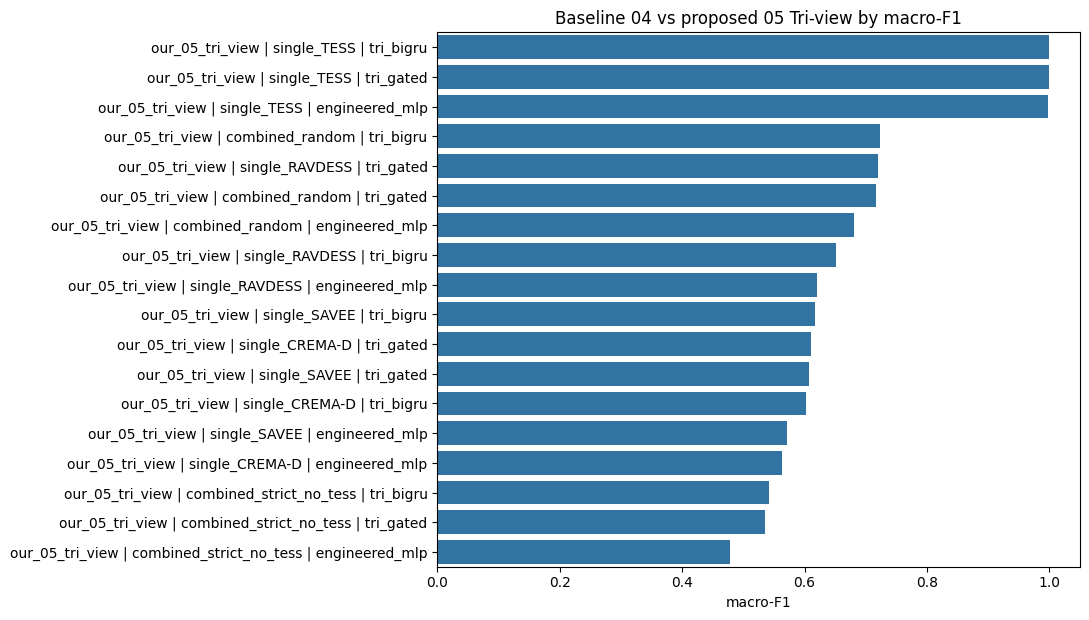

Reference models for report comparison:


,model,protocol,reported_accuracy_text,note
0,Ahmed et al. weighted ensemble 1D-CNN + CNN-LS...,"single-dataset, not clearly speaker-aware",TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CRE...,"Strong augmentation, recurrent temporal modeli..."
1,Lee & Nadeem MFCC 1D-CNN with channel/spatial ...,"single-dataset benchmark, split not clearly st...",SAVEE 97.49%; RAVDESS 99.23%; CREMA-D 89.31%; ...,Attention reweights informative MFCC channels ...
2,Chowdhury et al. DCRF-BiLSTM feature engineering,"individual and combined datasets, not clearly ...",RAVDESS 97.83%; SAVEE 97.02%; CREMA-D 95.10%; ...,"Uses richer acoustic features, augmentation, B..."


In [19]:
baseline_candidates = [
    PROJECT_ROOT / "04_Baseline_Per_Dataset_outputs" / "reports" / "baseline_per_dataset_metrics.csv",
    Path.cwd() / "04_Baseline_Per_Dataset_outputs" / "reports" / "baseline_per_dataset_metrics.csv",
    Path.cwd().parent / "04_Baseline_Per_Dataset_outputs" / "reports" / "baseline_per_dataset_metrics.csv",
    Path.cwd().parent / "04_Baseline_Models" / "reports" / "baseline_per_dataset_metrics.csv",
    Path("/kaggle/working/04_Baseline_Per_Dataset_outputs/reports/baseline_per_dataset_metrics.csv"),
    Path("D:/UTE/Speech Programming/Speech Project/04_Baseline_Models/reports/baseline_per_dataset_metrics.csv"),
]

baseline_df = None
for p in baseline_candidates:
    if p.exists():
        baseline_df = pd.read_csv(p)
        print("Loaded baseline 04 metrics:", p)
        break

comparison_rows = []
if baseline_df is not None:
    for _, r in baseline_df.iterrows():
        comparison_rows.append({
            "source": "our_04_baseline",
            "protocol": r.get("experiment", ""),
            "model": f"{r.get('feature_set', '')}_{r.get('model', '')}",
            "accuracy": r.get("accuracy", np.nan),
            "macro_f1": r.get("macro_f1", np.nan),
            "reported_accuracy_text": "",
            "note": "Classical ML baseline from notebook 04.",
        })
else:
    print("Baseline output not found yet. Run notebook 04 first if you want automatic comparison.")

for _, r in metrics_df.iterrows():
    comparison_rows.append({
        "source": "our_05_tri_view",
        "protocol": r.get("run_name", ""),
        "model": r.get("variant", ""),
        "accuracy": r.get("accuracy", np.nan),
        "macro_f1": r.get("macro_f1", np.nan),
        "reported_accuracy_text": "",
        "note": "Tri-view model: MFCC sequence + log-Mel image + engineered acoustic vector.",
    })

reference_rows = [
    {
        "source": "reference",
        "protocol": "single-dataset, not clearly speaker-aware",
        "model": "Ahmed et al. weighted ensemble 1D-CNN + CNN-LSTM + CNN-GRU",
        "accuracy": np.nan,
        "macro_f1": np.nan,
        "reported_accuracy_text": "TESS 99.46%; RAVDESS 95.62%; SAVEE 93.22%; CREMA-D 90.47%",
        "note": "Strong augmentation, recurrent temporal modeling and weighted probability ensemble.",
    },
    {
        "source": "reference",
        "protocol": "single-dataset benchmark, split not clearly strict speaker-aware",
        "model": "Lee & Nadeem MFCC 1D-CNN with channel/spatial attention",
        "accuracy": np.nan,
        "macro_f1": np.nan,
        "reported_accuracy_text": "SAVEE 97.49%; RAVDESS 99.23%; CREMA-D 89.31%; TESS 99.82%",
        "note": "Attention reweights informative MFCC channels and time regions.",
    },
    {
        "source": "reference",
        "protocol": "individual and combined datasets, not clearly strict speaker-aware",
        "model": "Chowdhury et al. DCRF-BiLSTM feature engineering",
        "accuracy": np.nan,
        "macro_f1": np.nan,
        "reported_accuracy_text": "RAVDESS 97.83%; SAVEE 97.02%; CREMA-D 95.10%; TESS 100%; R+T+S+E+C 93.76%",
        "note": "Uses richer acoustic features, augmentation, BiLSTM temporal context and DeepCRF structured prediction.",
    },
]

comparison_df = pd.DataFrame(comparison_rows)
reference_df = pd.DataFrame(reference_rows)
comparison_df.to_csv(REPORT_DIR / "baseline04_vs_05_tri_view_comparison.csv", index=False)
reference_df.to_csv(REPORT_DIR / "reference_model_literature_comparison.csv", index=False)

if len(comparison_df):
    display(comparison_df.sort_values("macro_f1", ascending=False, na_position="last"))
    plot_df = comparison_df.dropna(subset=["macro_f1"]).copy()
    if len(plot_df):
        plot_df["label"] = plot_df["source"] + " | " + plot_df["protocol"].astype(str) + " | " + plot_df["model"].astype(str)
        plot_df = plot_df.sort_values("macro_f1", ascending=False).head(30)
        plt.figure(figsize=(11, max(5, 0.35 * len(plot_df))))
        sns.barplot(data=plot_df, y="label", x="macro_f1", orient="h")
        plt.title("Baseline 04 vs proposed 05 Tri-view by macro-F1")
        plt.xlabel("macro-F1")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "baseline04_vs_05_tri_view_macro_f1.png", dpi=160)
        plt.show()

print("Reference models for report comparison:")
display(reference_df[["model", "protocol", "reported_accuracy_text", "note"]])


## 13. Save Summary and Package ZIP

Cell cuối lưu toàn bộ output, model, report, figure và cố gắng đóng gói cả notebook đã chạy. Trên Kaggle, file chính để tải nằm trong `/kaggle/working`.


In [20]:
summary = {
    "notebook": "05_Tri_View_Fusion_SER",
    "model_variants": MODEL_VARIANTS,
    "output_dir": str(OUTPUT_DIR),
    "metrics_csv": str(REPORT_DIR / "tri_view_metrics.csv"),
    "engineered_feature_source": ENGINEERED_FEATURE_SOURCE,
    "notes": "Use validation macro-F1 for model selection; compare random, strict and single-dataset protocols separately.",
}
with open(REPORT_DIR / "tri_view_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

zip_base = PROJECT_ROOT / "05_Tri_View_Fusion_outputs_package"
zip_path = shutil.make_archive(str(zip_base), "zip", OUTPUT_DIR)
print("OUTPUT ZIP:", zip_path)

# Package outputs + executed notebook if Kaggle exposes it.
PACKAGE_DIR = PROJECT_ROOT / "05_Tri_View_Fusion_export_package"
PACKAGE_DIR.mkdir(parents=True, exist_ok=True)

export_outputs_dir = PACKAGE_DIR / OUTPUT_DIR.name
if export_outputs_dir.exists():
    shutil.rmtree(export_outputs_dir)
shutil.copytree(OUTPUT_DIR, export_outputs_dir)

candidate_notebooks = []
candidate_notebooks.extend(Path("/kaggle/working").glob("*.ipynb"))
candidate_notebooks.extend(Path.cwd().glob("*.ipynb"))
candidate_notebooks = list(dict.fromkeys(candidate_notebooks))
preferred = [p for p in candidate_notebooks if "05" in p.name and ("Tri" in p.name or "tri" in p.name)]
notebook_to_copy = preferred[0] if preferred else (candidate_notebooks[0] if candidate_notebooks else None)

if notebook_to_copy is not None and notebook_to_copy.exists():
    copied_nb = PACKAGE_DIR / notebook_to_copy.name
    shutil.copy2(notebook_to_copy, copied_nb)
    print("Included notebook:", copied_nb)
else:
    print("Warning: could not auto-find executed notebook. Outputs are still packaged.")

manifest = {
    "notebook": "05_Tri_View_Fusion_SER",
    "model_variants": MODEL_VARIANTS,
    "output_dir": str(OUTPUT_DIR),
    "included_outputs_dir": str(export_outputs_dir),
    "included_notebook": str(notebook_to_copy) if notebook_to_copy is not None else None,
    "metrics_csv": str(REPORT_DIR / "tri_view_metrics.csv"),
    "summary_json": str(REPORT_DIR / "tri_view_summary.json"),
}
with open(PACKAGE_DIR / "export_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

FINAL_ZIP_BASE = PROJECT_ROOT / "05_Tri_View_Fusion_outputs_with_notebook"
FINAL_ZIP_PATH = shutil.make_archive(str(FINAL_ZIP_BASE), "zip", PACKAGE_DIR)
print("FINAL ZIP:", FINAL_ZIP_PATH)

try:
    from IPython.display import FileLink, display
    display(FileLink(str(FINAL_ZIP_PATH)))
    display(FileLink(str(zip_path)))
except Exception as e:
    print("Download link display failed:", e)
    print("You can download it from:", FINAL_ZIP_PATH)


OUTPUT ZIP: /kaggle/working/05_Tri_View_Fusion_outputs_package.zip
Included notebook: /kaggle/working/05_Tri_View_Fusion_export_package/__notebook__.ipynb
FINAL ZIP: /kaggle/working/05_Tri_View_Fusion_outputs_with_notebook.zip


/kaggle/working/05_Tri_View_Fusion_outputs_with_notebook.zip

/kaggle/working/05_Tri_View_Fusion_outputs_package.zip